In [1]:
import GWDALI as gw
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

### Setting detectors network

In [2]:
# 2nd Generation Detectors

det1 = {'name':'LIGO', 'lon':-119.41, 'lat': 46.46, 'rot': 216.00, 'shape':90}
det2 = {'name':'LIGO', 'lon':-90.77, 'lat': 30.56, 'rot': 288.00, 'shape':90}
det3 = {'name':'Virgo', 'lon':10.50, 'lat': 43.63, 'rot': 161.00, 'shape':90}
det4 = {'name':'Kagra', 'lon':137.31, 'lat': 36.41, 'rot': 118.31, 'shape':90}

# 3rd Generation Detectors

# Cosmic Explorer Coordinates
# https://cosmicexplorer.org/celocations.html
lon_CE_A = -125.0891
lat_CE_A = 45.64555

lon_CE_B = -94.
lat_CE_B = 29.

# Einstein Telecope Coordinates (Vaalserberg)
lon_ET = 6.02138
lat_ET = 50.75345

det_CE_A = {'name':'CE_20km','lon':lon_CE_A, 'lat':lat_CE_A, 'rot':190, 'shape':90}
det_CE_B = {'name':'CE_40km','lon':lon_CE_B, 'lat':lat_CE_B, 'rot':250, 'shape':90}

det_ET1 = {'name':'ET','lon':lon_ET, 'lat':lat_ET, 'rot':0, 'shape':60}
det_ET2 = {'name':'ET','lon':lon_ET, 'lat':lat_ET, 'rot':120, 'shape':60}
det_ET3 = {'name':'ET','lon':lon_ET, 'lat':lat_ET, 'rot':-120, 'shape':60}

detectors = [det1,det2,det3,det4, det_CE_A, det_CE_B, det_ET1, det_ET2, det_ET3]

### Plotting detectors coordinates/oriantation

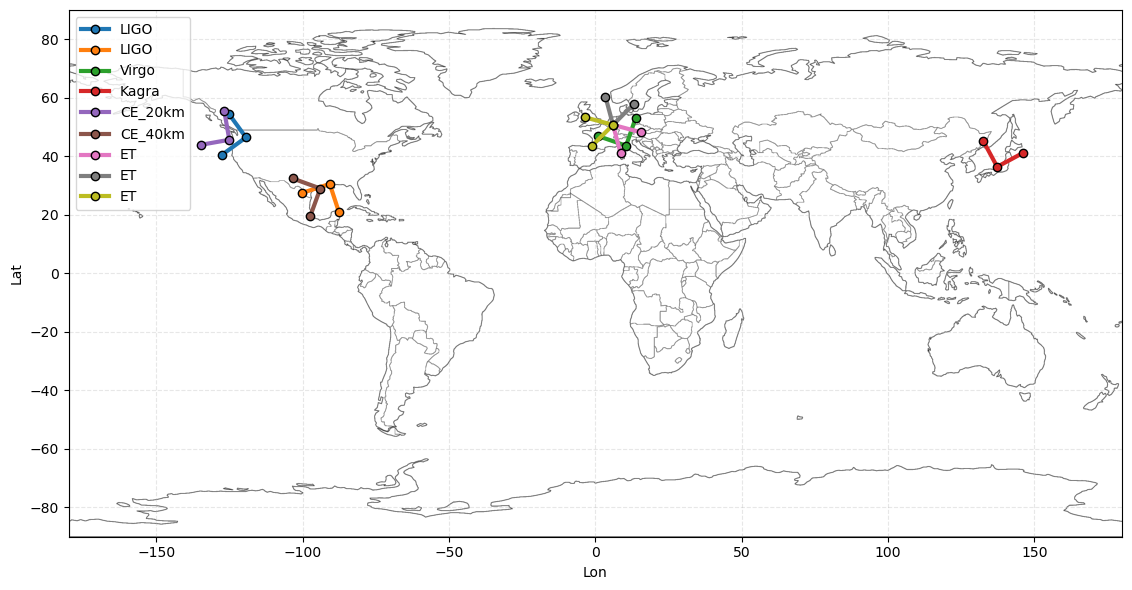

In [3]:
fig = gw.draw_detectors(detectors)

### Plotting Antenna Pattern Response
$$F\equiv \sqrt{ \sum_{a=1}^{N_{dets}}(F_{+,a})^2+(F_{\times,a})^2}$$

>> Getting Detector Response ...


100%|██████████| 50/50 [00:00<00:00, 142.56it/s]


Text(0.5, 0.98, '$F = \\sqrt{\\sum_a (F_{+,a}^2+F_{\\times,a}^2)}$')

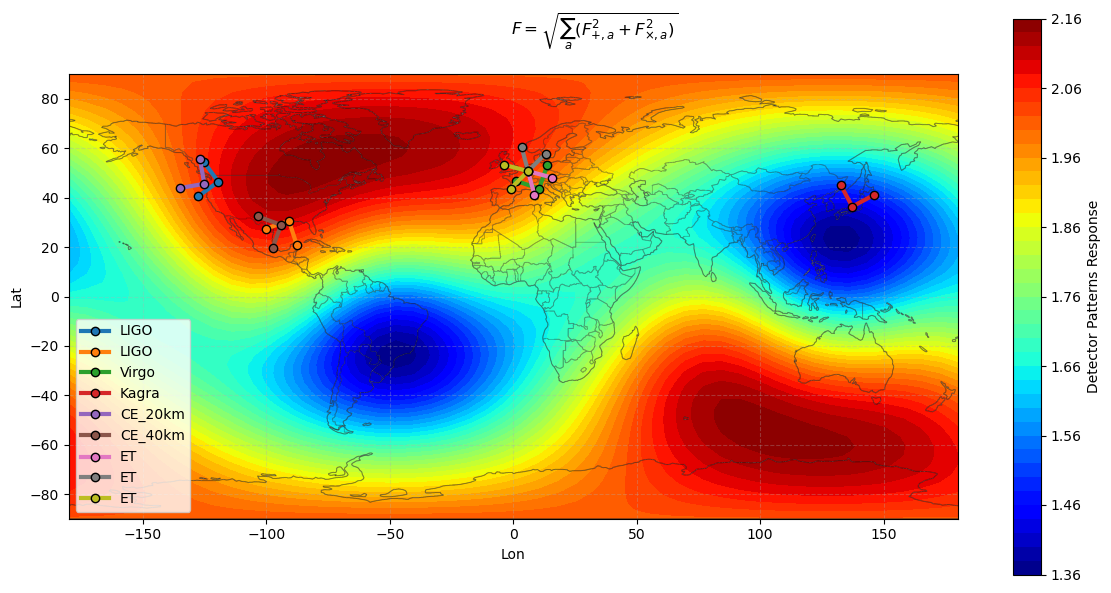

In [4]:
fig = gw.get_map(detectors,plot_map=True)
plt.suptitle("$F = \\sqrt{\\sum_a (F_{+,a}^2+F_{\\times,a}^2)}$")

### Getting Map Data for Alternative Plot (Aitoff Projection Map)

In [5]:
xx, yy, F = gw.get_map(detectors,plot_map=False)

>> Getting Detector Response ...


100%|██████████| 50/50 [00:00<00:00, 61.39it/s]


In [6]:
print(xx.min(), xx.max())
print(yy.min(), yy.max())

xx2 = xx[:, :-1]
yy2 = yy[:, :-1]
F2  = F[:, :-1]

-180.0 180.0
-90.0 90.0


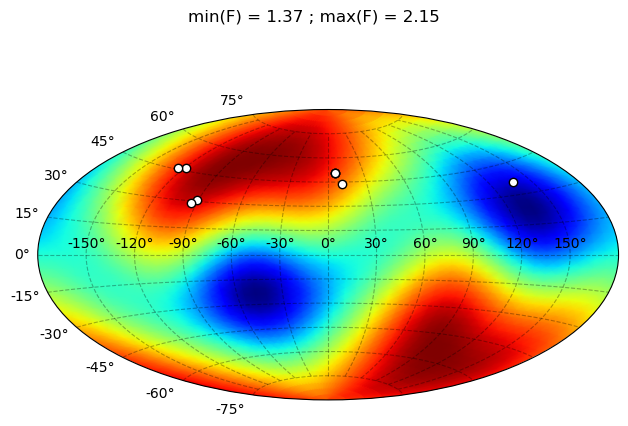

In [7]:


rad = np.pi/180

norm = mcolors.Normalize(vmin=np.min(F),vmax=np.max(F))

ax = plt.subplot(111,projection='aitoff')
plt.suptitle(f"min(F) = {np.min(F):.2f} ; max(F) = {np.max(F):.2f}")

c = ax.pcolormesh(
    xx * rad,
    yy * rad,
    F,
    cmap='jet',
    shading='gouraud'
)

for det in detectors:
    lon = det['lon']*rad
    lat = det['lat']*rad
    plt.plot(lon,lat,'wo',mec='k')
    
plt.grid(ls='--',color='k',alpha=0.3)

plt.tight_layout()

Text(0, 0.5, 'Characteristic Strain')

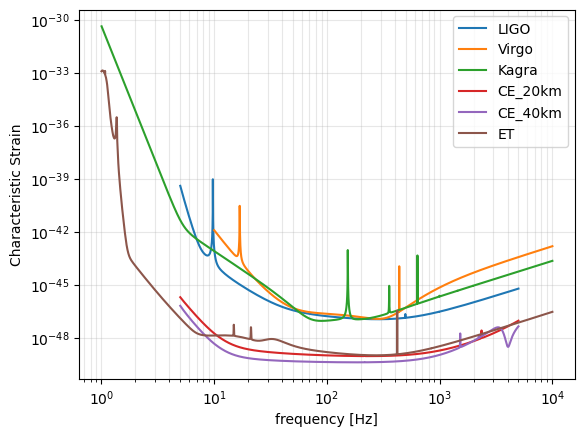

In [8]:
dets = [] ; names = []
for det in detectors:
    name = det['name']
    if not name in names:
        names.append(name)
        dets.append(det)

for det in dets:
    Sn, freq = gw.lib.Tensors.get_Sn(det['name'])
    Sc = np.sqrt(freq*Sn)

    plt.loglog(freq,Sn,label=det['name'])

plt.legend()
plt.grid(which='both',alpha=.3)
plt.xlabel('frequency [Hz]')
plt.ylabel('Characteristic Strain')